<a href="https://colab.research.google.com/github/ummehabiba-m/-betabytez-aiml-task1-ummeHabiba/blob/main/heart_disease_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction — Classification with a Simple Web UI

**Task:** Train and evaluate machine learning models to predict the presence
of heart disease in a patient based on clinical features (age, cholesterol,
chest pain type, etc.), then deploy the best-performing model behind a
simple Streamlit web interface so a non-technical user can get predictions
without touching any code.

**Dataset:** UCI Heart Disease dataset (303 patient records, 13 clinical
features, binary target: presence or absence of heart disease)

**Workflow:** Exploratory Data Analysis → Preprocessing → Model Training
(Logistic Regression & Random Forest) → Evaluation → Model Saving →
Streamlit Deployment

**Author:** UMME HABIBA MALIK

# **LOADING THE DATASET**

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Dataset: UCI Heart Disease
- age: age in years
- sex: 1 = male, 0 = female
- cp: chest pain type (0–3, 4 categories)
- trestbps: resting blood pressure
- chol: serum cholesterol (mg/dl)
- fbs: fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
- restecg: resting ECG results (0–2)
- thalach: max heart rate achieved
- exang: exercise-induced angina (1 = yes, 0 = no)
- oldpeak: ST depression induced by exercise
- slope: slope of peak exercise ST segment
- ca: number of major vessels colored by fluoroscopy (0–4)
- thal: thalassemia (blood disorder) type
- target: 1 = has heart disease, 0 = no heart disease

# **Exploratory Data Analysis (EDA).**

# Step 1 — Basic shape and info

In [5]:
# How many rows and columns do we have?
print("Shape:", df.shape)

# Data types and non-null counts for each column
df.info()

Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# Check for missing values explicitly

In [6]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
print("Shape:", df.shape)
df['target'].value_counts()

Shape: (303, 14)


,count
target,
1,165
0,138


# Summary

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Check class balance

In [9]:
df['target'].value_counts()

,count
target,
1,165
0,138


# Visualize the class balance

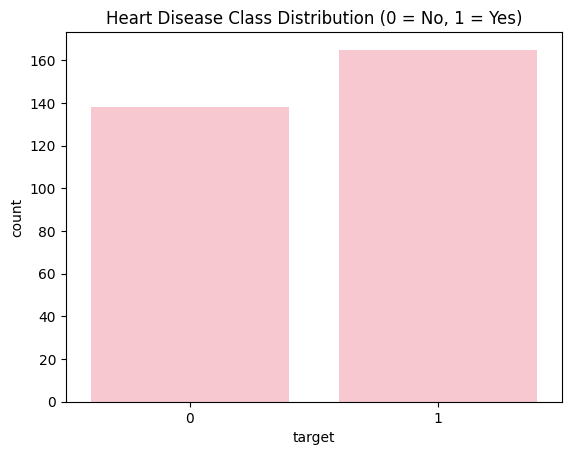

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='target', data=df,color='pink')
plt.title("Heart Disease Class Distribution (0 = No, 1 = Yes)")
plt.show()

# Correlation heatmap (which features relate to heart disease most)

Shows how strongly each feature relates to every other feature — including the target. Numbers close to +1 or -1 mean strong relationship; close to 0 means weak/no relationship

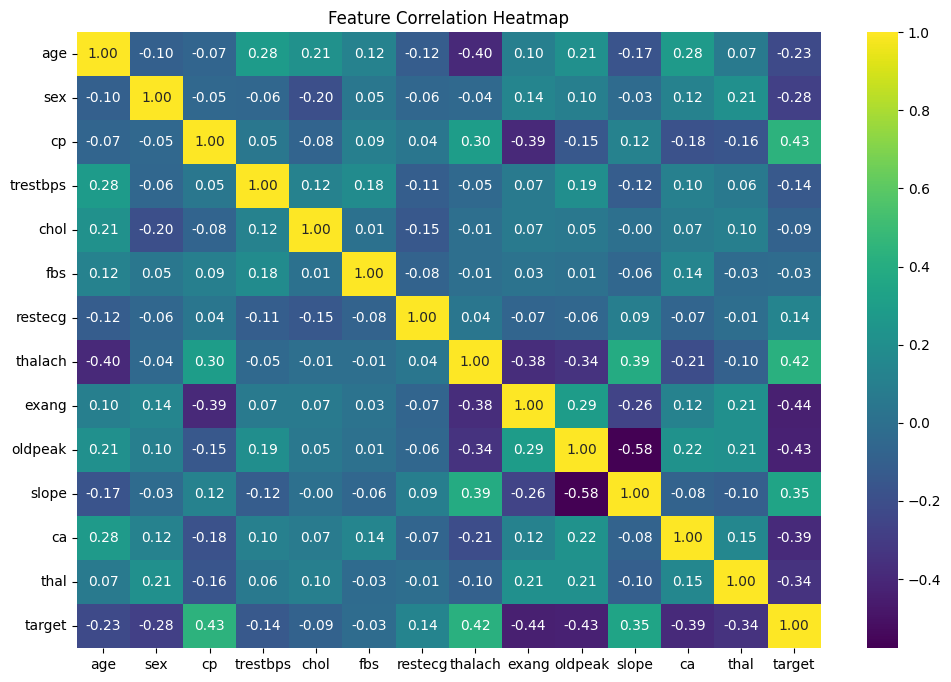

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Feature Correlation Heatmap")
plt.show()

# EDA Summary:

The Heart Disease dataset contains 303 patient records with 13 clinical
features and 1 target column, and has no missing values across any column.
The target classes are fairly balanced, with 165 patients (54.5%) diagnosed
with heart disease and 138 (45.5%) without, so no class-imbalance handling
(like oversampling) was needed.

The correlation heatmap shows that chest pain type (cp, +0.43) and maximum
heart rate achieved (thalach, +0.42) have the strongest positive relationship
with heart disease — meaning certain chest pain types and higher heart rates
during exercise are associated with a positive diagnosis. Exercise-induced
angina (exang, -0.44) and ST depression from exercise (oldpeak, -0.43) show
the strongest negative relationships, meaning their presence/higher values
are associated with a lower likelihood of heart disease in this dataset.
Overall, no single feature dominates, suggesting a combination of features
will be needed for accurate prediction — which is expected for a medical
classification problem like this.

# Stage 3: **Preprocessing**

ML models only understand numbers, and they work best when those numbers are on similar scales. Right now our data is already mostly numeric (good news, since UCI Heart Disease is pre-encoded), but a few columns are actually categories pretending to be numbers (like cp = chest pain type, which is 0/1/2/3 but those numbers don't mean "more" or

# Identify categorical vs. numerical columns

In [16]:
# Categorical columns (numbers that represent categories, not quantities)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Numerical columns (actual continuous/ordered values)
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


**Why this split matters:** sex is 0/1 — that's fine as-is (binary). But cp (chest pain type) has 4 categories (0,1,2,3) with no real order — if we leave it as a plain number, the model might wrongly assume "type 3 is more than type 1" in a mathematical sense. So we'll one-hot encode these.

# One-hot encode the categorical columns

In [17]:
# One-hot encoding: turns each category into its own 0/1 column
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,63,145,233,150,2.3,1,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,37,130,250,187,3.5,1,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,41,130,204,172,1.4,1,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
3,56,120,236,178,0.8,1,True,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,57,120,354,163,0.6,1,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False


**What pd.get_dummies does:** for a column like cp with values 0,1,2,3, it creates new columns like cp_1, cp_2, cp_3 — each is 1 if that row belongs to that category, 0 otherwise. drop_first=True drops one category to avoid redundancy (standard practice, called avoiding the "dummy variable trap")

# Separate features (X) from target (y)

In [18]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 22)
Target shape: (303,)


# Split into training and testing sets

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


**Why we split the data:** we train the model on 80% of patients, then test it on the remaining 20% it has never seen — this tells us how well it would perform on new, real patients, instead of just memorizing the training data.

random_state=42 just makes the split reproducible (same split every time you run it).
stratify=y makes sure both the train and test sets keep the same 54%/46% class balance we found in EDA.

# Scale the numerical features

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train.head()

,age,trestbps,chol,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
19,1.610480,0.461840,-0.123235,0.039942,0.604853,False,False,False,True,False,...,False,False,True,False,True,False,False,False,True,False
247,1.282051,1.575595,0.023366,-1.373486,-0.890458,True,True,False,False,False,...,True,True,False,False,False,True,False,True,False,False
289,0.077810,-0.206413,-0.835301,-0.917541,0.770998,False,False,False,False,False,...,True,True,False,True,False,False,False,False,False,True
288,0.296763,-1.208792,1.887302,-0.324813,1.601727,True,False,False,False,False,...,True,True,False,True,False,False,False,False,False,True
60,1.829433,-1.208792,0.421285,-0.917541,-0.890458,False,False,True,False,True,...,False,False,True,True,False,False,False,False,True,False


**Why we scale: **columns like chol (cholesterol, ranging ~120-400) and oldpeak (ranging ~0-6) are on very different scales. Without scaling, a model like Logistic Regression might think cholesterol matters more just because its numbers are bigger. StandardScaler converts each column to have mean 0 and standard deviation 1 — putting them on equal footing.

# Preprocessing Summary:
- No missing values needed handling.
- Categorical columns (sex, cp, fbs, restecg, exang, slope, ca, thal) were
  one-hot encoded, expanding the feature set from 13 to 22 columns.
- Data was split 80/20 into training (242 samples) and testing (61 samples),
  stratified to preserve the original class balance.
- Numerical columns (age, trestbps, chol, thalach, oldpeak) were scaled using
  StandardScaler, fit only on the training set to avoid data leakage.

# Stage 4: Train Logistic Regression + Random Forest

we'll train two different types of models on the same training data, then later compare which one predicts heart disease better. Logistic Regression is simple and fast (draws a straight-line-like boundary between classes). Random Forest is more powerful (builds many decision trees and combines their votes)

# Train Logistic Regression

 Check the data types

In [26]:
X_train.dtypes

,0
age,float64
trestbps,float64
chol,float64
thalach,float64
oldpeak,float64
sex_1,float64
cp_1,float64
cp_2,float64
cp_3,float64
fbs_1,float64


Convert booleans to integers (if needed)

In [27]:
X_train = X_train.astype(int) if X_train.select_dtypes(include='bool').shape[1] > 0 else X_train
X_test = X_test.astype(int) if X_test.select_dtypes(include='bool').shape[1] > 0 else X_test

In [28]:
X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

Increase max_iter and retrain

In [30]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42, max_iter=5000)
log_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


**What's happening:** LogisticRegression() creates an untrained model. .fit(X_train, y_train) is where the actual "learning" happens — it looks at all 242 training patients and their known outcomes, and adjusts its internal math to best separate "has heart disease" from "doesn't." max_iter=1000 just gives it enough attempts to converge (find a good solution) — sometimes the default (100) isn't enough and it warns you.

# Train Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


# Get predictions from both models

In [32]:
log_predictions = log_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

print("Logistic Regression predictions (first 10):", log_predictions[:10])
print("Random Forest predictions (first 10):", rf_predictions[:10])
print("Actual values (first 10):", y_test.values[:10])

Logistic Regression predictions (first 10): [0 0 0 1 0 0 1 0 1 0]
Random Forest predictions (first 10): [0 0 0 1 0 0 1 1 1 1]
Actual values (first 10): [0 0 0 0 0 0 1 0 1 0]


# **Stage 5: Evaluation (Accuracy, Precision, Recall, F1-Score)**

**Accuracy:** out of all predictions, what % were correct overall


**Precision:** when the model says "has heart disease," how often is it actually right (avoids false alarms)






**Recall:** out of all patients who actually have heart disease, how many did the model correctly catch (avoids missing real cases — very important in medical contexts!)


**F1-Score:** a balance between precision and recall, useful when you care about both

# Import evaluation tools

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate all 4 metrics for both models

In [34]:
# Logistic Regression metrics
log_accuracy = accuracy_score(y_test, log_predictions)
log_precision = precision_score(y_test, log_predictions)
log_recall = recall_score(y_test, log_predictions)
log_f1 = f1_score(y_test, log_predictions)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("=== Logistic Regression ===")
print(f"Accuracy:  {log_accuracy:.3f}")
print(f"Precision: {log_precision:.3f}")
print(f"Recall:    {log_recall:.3f}")
print(f"F1-Score:  {log_f1:.3f}")

print("\n=== Random Forest ===")
print(f"Accuracy:  {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall:    {rf_recall:.3f}")
print(f"F1-Score:  {rf_f1:.3f}")

=== Logistic Regression ===
Accuracy:  0.869
Precision: 0.857
Recall:    0.909
F1-Score:  0.882

=== Random Forest ===
Accuracy:  0.738
Precision: 0.743
Recall:    0.788
F1-Score:  0.765


# Build a clean comparison table

In [35]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy],
    'Precision': [log_precision, rf_precision],
    'Recall': [log_recall, rf_recall],
    'F1-Score': [log_f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.868852,0.857143,0.909091,0.882353
1,Random Forest,0.737705,0.742857,0.787879,0.764706


# Model Comparison:

Logistic Regression outperformed Random Forest across all four metrics
(Accuracy: 86.9% vs 73.8%, F1-Score: 0.882 vs 0.765). This is likely because
the dataset is relatively small (only 242 training samples) and the
relationship between features and the target is fairly linear/simple —
Logistic Regression is well-suited to this since it doesn't need much data
to find a good decision boundary. Random Forest, being a more complex model
with 100 decision trees, is more prone to overfitting on smaller datasets,
which likely hurt its performance on unseen test data. Logistic Regression's
high recall (0.909) is especially valuable in a medical context, since it
means the model misses very few actual heart disease cases. Based on these
results, Logistic Regression was selected as the final model for deployment.



# Save the trained model


In [37]:
import os
os.makedirs('model', exist_ok=True)

In [38]:
import joblib

# Save the trained model
joblib.dump(log_model, 'model/heart_disease_model.pkl')

# Also save the scaler — we'll need it later to preprocess new user input in the Streamlit app!
joblib.dump(scaler, 'model/scaler.pkl')

# Save the column names/order — critical so the Streamlit app builds input in the exact same format
joblib.dump(X_train.columns.tolist(), 'model/model_columns.pkl')

print("Model, scaler, and column list saved successfully!")

Model, scaler, and column list saved successfully!
